## REAL OPTIONS — BUYPERP
# **YEAR 1: WHEN TO BUY THE ANNUAL COPPER/ALUMINIUM REQUIREMENT**

Every year the company needs a fixed quantity of copper and aluminium as
cable inputs. It gets **n scheduled chances during the year** (here: the
last trading day of each month, so n=12) to place that one, full purchase.
If it never actively decides to buy earlier, it is forced to buy at the
last chance (the end of the year). The question this script answers:

**How much is this timing flexibility worth, compared to (a) being forced
to buy at year-end, (b) buying immediately, and (c) buying without any
real market-timing skill (a random, split-up purchase)?**

This mirrors the Simplico gold mine lattice from `local/DP_M7_L1.ipynb`
(a binomial tree, solved by backward induction) — except the company is
*minimizing a cost* rather than *maximizing a payoff*, and the underlying
is a combined copper+aluminium "basket cost" instead of a single commodity.
The reusable pricing logic lives in `src/real_options/bermudan_purchase.py`
(tested in `tests/test_bermudan_purchase.py`) so the same functions can be
called again for Year 2, Year 3, ... once real market data for those years
exists — this script itself only wires inputs together and presents results.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.real_options import bermudan_purchase as bp

### Configuration

Everything that defines *this* year's decision problem lives here, at the
top of the file, so you can change the business assumptions or switch a
verification procedure on/off without touching any logic below.

In [2]:
# --- Business quantities (the annual cable-input requirement) ---------------
CU_TONNES = 100.0  # copper required this year, tonnes
AL_TONNES = 100.0  # aluminium required this year, tonnes
N_OPPORTUNITIES = 12  # scheduled purchase dates this year (monthly month-end)
YEAR_1_MONTH_LABELS = [
    "Sep", "Oct", "Nov", "Dec", "Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug",
]  # fmt: skip

# --- Toggle switches for the optional verification procedures ---------------
# Both are Monte Carlo based and independent of each other and of the core
# lattice computation above — turn either off to skip its (small) extra
# runtime cost. Note: the CORE result's EUR figure always uses proper
# execution-date FX conversion (see "Currency conversion" below) regardless
# of these toggles — they only affect the two cross-check baselines.
INCLUDE_MC_VERIFICATION_ANCHORS = True  # re-derive baselines A & B via simulation
INCLUDE_RANDOM_PROPORTIONAL_BASELINE = True  # baseline C: 3 random dates, 1/3 each

N_SIMULATIONS = 10_000
MONTE_CARLO_SEED = 42

### Load the input data

Both files were produced by `src/data_collection/pipeline.py` (run via
`python main.py` from the project root) and copied into this folder
specifically so this script needs no path configuration at all.

In [3]:
metals = pd.read_csv("metals_prices.csv", parse_dates=["date"])
sofr = pd.read_csv("sofr_rate.csv", parse_dates=["date"])

metals.tail(3)

,date,cu_usd_per_tonne,al_usd_per_tonne,eur_usd_rate,cu_eur_per_tonne,al_eur_per_tonne
754,2026-06-30,13341.0,3105.5,1.1394,11708.794102,2725.557311
755,2026-07-01,13170.0,3075.0,1.1383,11569.884916,2701.396820
756,2026-07-02,13202.0,3061.5,1.1399,11581.717695,2685.761909


### Build the combined "basket cost" series and estimate sigma and mu

The purchase decision only ever cares about the *total* cost of the year's
copper + aluminium requirement, so — as explained in
`bermudan_purchase.py` — we build ONE cost series and estimate both its
volatility (sigma) AND its real-world drift (mu) directly from its own
3 years of historical returns. Using mu instead of a synthetic risk-neutral
rate is deliberate: see the next markdown cell. The EUR/USD rate gets the
exact same treatment (its own sigma/mu from its own history), so it can
later be simulated forward just like the metal cost.

In [4]:
metals["basket_cost_usd"] = CU_TONNES * metals["cu_usd_per_tonne"] + AL_TONNES * metals["al_usd_per_tonne"]

sigma = bp.annualized_volatility(metals["basket_cost_usd"])
mu = bp.annualized_drift(metals["basket_cost_usd"])
s0_usd = float(metals["basket_cost_usd"].iloc[-1])

fx_sigma = bp.annualized_volatility(metals["eur_usd_rate"])
fx_mu = bp.annualized_drift(metals["eur_usd_rate"])
fx0 = float(metals["eur_usd_rate"].iloc[-1])

# The risk-free discount rate: latest SOFR (USD, %) converted to a decimal.
r = float(sofr["sofr_rate_pct"].iloc[-1]) / 100.0

dt = 1.0 / N_OPPORTUNITIES  # one month, expressed in years

print(f"S0 (today's basket cost):          {s0_usd:>12,.0f} USD")
print(f"Annualized volatility sigma:       {sigma:>12.1%}")
print(f"Annualized real-world drift mu:    {mu:>12.1%}  (historical, 3y)")
print(f"Risk-free discount rate r (SOFR):  {r:>12.2%}")
print(f"EUR/USD rate now (fx0):            {fx0:>12.4f}")
print(f"EUR/USD sigma / mu (historical):   {fx_sigma:>12.1%} / {fx_mu:.1%}")

S0 (today's basket cost):             1,626,350 USD
Annualized volatility sigma:              18.4%
Annualized real-world drift mu:           14.7%  (historical, 3y)
Risk-free discount rate r (SOFR):         3.66%
EUR/USD rate now (fx0):                  1.1399
EUR/USD sigma / mu (historical):           6.9% / 1.5%


### Why real-world drift, not a textbook risk-neutral rate

A first version of this model built the lattice the "textbook derivatives"
way (tree probability driven by `r`). That construction makes buying at
ANY date — now, at year-end, or via optimal timing — cost exactly `S0` in
expectation: a linear "buy at spot" payoff has **zero** timing value under
a no-arbitrage measure (you can't out-time a fairly priced asset — that's
what "fairly priced" means). The Simplico gold mine avoids this only
because its payoff is nonlinear (floored at zero), not because its tree
is built differently.

This company isn't trading a hedgeable derivative for arbitrage-free
resale, though — it's making a physical purchase decision based on how
copper and aluminium have actually, historically moved. So the tree below
uses `mu` (estimated straight from our 3 years of collected data) to drive
the probability of an up-move, while still discounting at the risk-free
rate `r` — a standard simplification in practitioner real-options analysis
for decisions that can't be perfectly hedged in a market. We show the
textbook risk-neutral (zero-value) result too, purely so you can see the
difference the drift choice makes.

In [5]:
risk_neutral_reference_cost = bp.price_bermudan_purchase_option(s0_usd, sigma, r, r, N_OPPORTUNITIES, dt)
print(f"Textbook risk-neutral cost (drift=r): {risk_neutral_reference_cost:>12,.0f} USD  (== S0)")

Textbook risk-neutral cost (drift=r):    1,626,350 USD  (== S0)


### The core valuation: optimal purchase timing via backward induction

`price_bermudan_purchase_option` walks backward from the last (forced)
opportunity to the first, and at every earlier opportunity compares
"buy now" against the discounted expected value of waiting — exactly the
lease-value backward induction in `local/DP_M7_L1.ipynb`, but minimizing
cost instead of maximizing payoff, and using real-world drift `mu`.

In [6]:
real_options_cost = bp.price_bermudan_purchase_option(s0_usd, sigma, mu, r, N_OPPORTUNITIES, dt)

print(f"Real-options cost (optimal timing):  {real_options_cost:>12,.0f} USD")
print(f"                        vs. S0:      {s0_usd:>12,.0f} USD")

Real-options cost (optimal timing):     1,641,389 USD
                        vs. S0:         1,626,350 USD


### Currency conversion: at the EXECUTION date, not today's rate

Converting every USD figure with today's flat EUR/USD rate would silently
assume the purchase always happens today — wrong for anything that isn't
Baseline A. Instead, we simulate the EUR/USD rate forward (its own
historical sigma/mu, independent of the metal cost) alongside the basket
cost, and — for the adaptive policy — replay the lattice's OWN exercise
thresholds against those simulated cost paths to find each path's actual
execution month, then convert THAT path's USD cash flow using THAT path's
simulated FX rate on THAT month. Averaging over paths gives the real-options
cost in EUR, properly reflecting that this purchase might happen in month 1
or month 12, at whatever EUR/USD rate prevails then — not a single snapshot.

This MC replay is also an independent cross-check on the closed-form
lattice value above: expect close agreement, with a small (~0.5%), stable
gap from the fact that the exercise threshold comes from a 12-step
*discrete* tree while the replay path is continuous — a known
discretization effect, not a bug (see `REPORT.md`).

In [7]:
exercise_thresholds = bp.bermudan_exercise_thresholds(s0_usd, sigma, mu, r, N_OPPORTUNITIES, dt)
cost_paths = bp.simulate_gbm_paths(
    s0_usd, sigma, mu, N_OPPORTUNITIES, dt, N_SIMULATIONS, seed=MONTE_CARLO_SEED
)
fx_paths = bp.simulate_gbm_paths(
    fx0, fx_sigma, fx_mu, N_OPPORTUNITIES, dt, N_SIMULATIONS, seed=MONTE_CARLO_SEED + 100
)

adaptive_mc = bp.simulate_adaptive_purchase_baseline(
    cost_paths, exercise_thresholds, r, dt, N_OPPORTUNITIES, fx_paths=fx_paths
)
real_options_cost_eur = adaptive_mc["mean_eur"]

print(f"Real-options cost, MC replay (USD): {adaptive_mc['mean']:>12,.0f}")
print(f"                    closed form:   {real_options_cost:>12,.0f} USD")
print(f"Real-options cost, execution-date EUR: {real_options_cost_eur:>12,.0f} EUR")
print(f"Average exercise month (1=Sep .. 12=Aug): {adaptive_mc['mean_exercise_month']:.1f}")

Real-options cost, MC replay (USD):    1,649,324
                    closed form:      1,641,389 USD
Real-options cost, execution-date EUR:    1,444,736 EUR
Average exercise month (1=Sep .. 12=Aug): 1.4


### Baseline A — buy immediately (no flexibility at all)

The simplest possible policy: commit to the full purchase today, at
whatever the current basket cost happens to be. "Execution date" for this
baseline is unambiguously today, so its EUR figure uses today's rate `fx0`
directly — no simulation needed. Note: if `mu` is well above `r` (i.e.
copper/aluminium have historically trended up faster than money grows
risk-free), it's possible for this to actually beat the optimal-timing
strategy — see the markdown cell further down for why that is a genuine
insight, not a bug.

In [8]:
baseline_immediate = bp.baseline_immediate_purchase_cost(s0_usd)
baseline_immediate_eur = baseline_immediate / fx0
option_value_vs_immediate = baseline_immediate - real_options_cost
option_value_vs_immediate_eur = baseline_immediate_eur - real_options_cost_eur

print(
    f"Baseline A (buy now):        {baseline_immediate:>12,.0f} USD  |  {baseline_immediate_eur:>12,.0f} EUR"
)
print(f"Option value vs. buying now: {option_value_vs_immediate:>12,.0f} USD")
print(f"                             {option_value_vs_immediate_eur:>12,.0f} EUR")

Baseline A (buy now):           1,626,350 USD  |     1,426,748 EUR
Option value vs. buying now:      -15,039 USD
                                  -17,988 EUR


### Baseline B — forced to wait until year-end (no active timing either)

The USD figure is a closed form (summing over the lattice's own terminal
probability distribution). Unlike Baseline A, the optimal-timing strategy
is **guaranteed** to cost no more than this baseline, for any `mu`: having
several chances to react is never worse than being limited to only the
very last one.

In [9]:
baseline_forced_last = bp.baseline_forced_last_date_cost_closed_form(
    s0_usd, sigma, mu, r, N_OPPORTUNITIES, dt
)
option_value_vs_forced_last = baseline_forced_last - real_options_cost

print(f"Baseline B (forced, year-end):        {baseline_forced_last:>12,.0f} USD")
print(f"Option value vs. forced year-end:     {option_value_vs_forced_last:>12,.0f} USD")

Baseline B (forced, year-end):           1,816,290 USD
Option value vs. forced year-end:          174,901 USD


### Verification 1 (toggle: `INCLUDE_MC_VERIFICATION_ANCHORS`)

Independently re-derives Baselines A and B by simulating price paths
(under the same real-world drift `mu`) and averaging, instead of relying
only on the formulas above — and, using the same `fx_paths` as the core
result above, gives Baseline B's EUR figure using the EUR/USD rate at
EACH path's own year-end, not today's rate. Baseline A's MC estimate has
zero simulated variance almost by definition (the cost is known and paid
today, before any randomness unfolds) — a useful confirmation the
simulation is wired correctly, not just a formality.

In [10]:
if INCLUDE_MC_VERIFICATION_ANCHORS:
    mc_anchors = bp.verify_anchor_baselines_via_monte_carlo(
        cost_paths, r, dt, N_OPPORTUNITIES, fx_paths=fx_paths
    )
    baseline_forced_last_eur = mc_anchors["forced_last_mean_eur"]
    option_value_vs_forced_last_eur = baseline_forced_last_eur - real_options_cost_eur

    print(f"MC Baseline A: mean={mc_anchors['immediate_mean']:,.0f}  std={mc_anchors['immediate_std']:,.2f}")
    print(
        f"MC Baseline B: mean={mc_anchors['forced_last_mean']:,.0f}  std={mc_anchors['forced_last_std']:,.2f}"
    )
    print(f"Closed-form Baseline A: {baseline_immediate:,.0f} | Baseline B: {baseline_forced_last:,.0f}")
    print(f"Baseline B in EUR (at its own execution-date FX rate): {baseline_forced_last_eur:,.0f} EUR")
else:
    # Fallback: without the simulation, we can't know each path's own future
    # FX rate, so this uses today's flat rate as a labeled approximation.
    baseline_forced_last_eur = baseline_forced_last / fx0
    option_value_vs_forced_last_eur = baseline_forced_last_eur - real_options_cost_eur
    print("Skipped (toggle off) — Baseline B EUR uses today's flat rate as an approximation")

MC Baseline A: mean=1,626,350  std=0.00
MC Baseline B: mean=1,812,144  std=338,083.66
Closed-form Baseline A: 1,626,350 | Baseline B: 1,816,290
Baseline B in EUR (at its own execution-date FX rate): 1,573,719 EUR


### Verification 2 / Baseline C (toggle: `INCLUDE_RANDOM_PROPORTIONAL_BASELINE`)

A "no market-timing skill" baseline: instead of choosing the best date,
buy exactly 1/3 of the annual quantity at each of 3 *randomly* chosen
month-ends (a different random triple per simulated year). This answers
the practical question: what does it cost to just spread purchases out
arbitrarily, without ever looking at the price? Each third is converted to
EUR at its own purchase date's simulated FX rate.

In [11]:
if INCLUDE_RANDOM_PROPORTIONAL_BASELINE:
    baseline_random = bp.simulate_random_three_of_n_baseline(
        cost_paths, r, dt, N_OPPORTUNITIES, seed=MONTE_CARLO_SEED + 1, fx_paths=fx_paths
    )
    option_value_vs_random = baseline_random["mean"] - real_options_cost
    option_value_vs_random_eur = baseline_random["mean_eur"] - real_options_cost_eur

    print(
        f"Baseline C (random 3-of-{N_OPPORTUNITIES}, 1/3 each): "
        f"mean={baseline_random['mean']:,.0f} USD  |  {baseline_random['mean_eur']:,.0f} EUR"
    )
    print(f"Option value vs. random proportional buying: {option_value_vs_random:,.0f} USD")
else:
    print("Skipped (INCLUDE_RANDOM_PROPORTIONAL_BASELINE = False)")

Baseline C (random 3-of-12, 1/3 each): mean=1,727,639 USD  |  1,507,221 EUR
Option value vs. random proportional buying: 86,249 USD


### Summary — in USD and EUR (EUR converted at each scenario's own execution date)

In [12]:
summary = pd.DataFrame(
    {
        "USD": {
            "S0 / Baseline A (buy now)": baseline_immediate,
            "Baseline B (forced, year-end)": baseline_forced_last,
            "Real-options cost (optimal timing)": real_options_cost,
            "Option value vs. A (buy now)": option_value_vs_immediate,
            "Option value vs. B (forced year-end)": option_value_vs_forced_last,
        },
        "EUR": {
            "S0 / Baseline A (buy now)": baseline_immediate_eur,
            "Baseline B (forced, year-end)": baseline_forced_last_eur,
            "Real-options cost (optimal timing)": real_options_cost_eur,
            "Option value vs. A (buy now)": option_value_vs_immediate_eur,
            "Option value vs. B (forced year-end)": option_value_vs_forced_last_eur,
        },
    }
)
if INCLUDE_RANDOM_PROPORTIONAL_BASELINE:
    summary.loc["Baseline C (random 3-of-n)", ["USD", "EUR"]] = [
        baseline_random["mean"],
        baseline_random["mean_eur"],
    ]
    summary.loc["Option value vs. C (random)", ["USD", "EUR"]] = [
        option_value_vs_random,
        option_value_vs_random_eur,
    ]

summary.round(0)

,USD,EUR
S0 / Baseline A (buy now),1626350.0,1426748.0
"Baseline B (forced, year-end)",1816290.0,1573719.0
Real-options cost (optimal timing),1641389.0,1444736.0
Option value vs. A (buy now),-15039.0,-17988.0
Option value vs. B (forced year-end),174901.0,128983.0
Baseline C (random 3-of-n),1727639.0,1507221.0
Option value vs. C (random),86249.0,62485.0


### A quick look at the lattice's decision boundary

For intuition: at each opportunity, how far would the price need to have
fallen (as a fraction of S0) before it's worth buying rather than
continuing to wait? Plotting the cheapest attainable node per month
visualizes the same "switching boundary" idea as
`local/DP_M7_L4.ipynb`'s coal/renewables example.

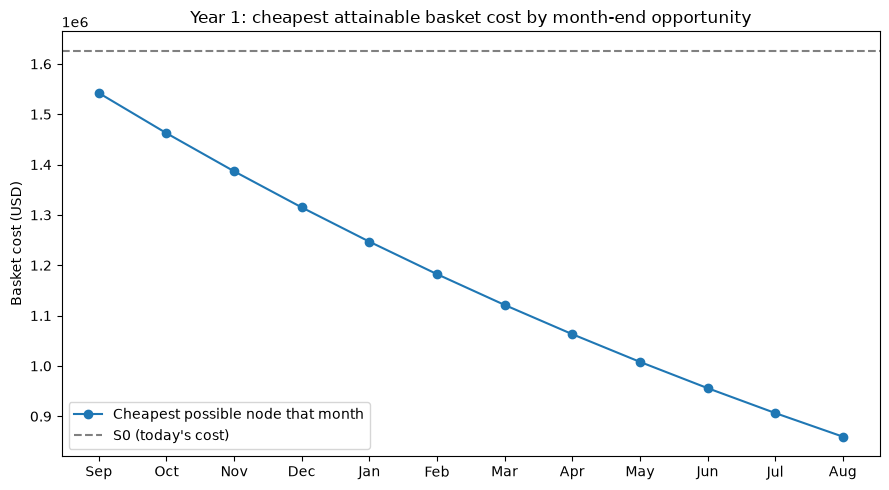

In [13]:
months = np.arange(1, N_OPPORTUNITIES + 1)
u, d, _ = bp.binomial_parameters(sigma, mu, dt)
lowest_node_cost_per_month = [s0_usd * d**m for m in months]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    YEAR_1_MONTH_LABELS, lowest_node_cost_per_month, marker="o", label="Cheapest possible node that month"
)
ax.axhline(s0_usd, color="grey", linestyle="--", label="S0 (today's cost)")
ax.set_ylabel("Basket cost (USD)")
ax.set_title("Year 1: cheapest attainable basket cost by month-end opportunity")
ax.legend()
fig.tight_layout()